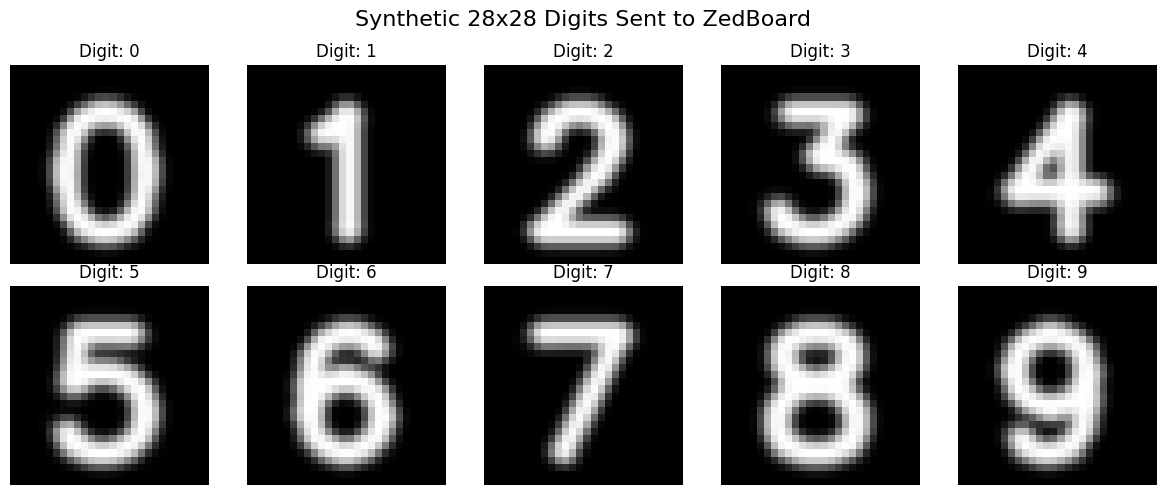

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def create_synthetic_digit(digit):
    # Create a completely blank 28x28 black canvas
    img = np.zeros((28, 28), dtype=np.uint8)
    
    # Setup the font and text parameters
    text = str(digit)
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 0.8
    thickness = 2
    
    # Calculate coordinates to perfectly center the digit
    text_size = cv2.getTextSize(text, font, font_scale, thickness)[0]
    text_x = (28 - text_size[0]) // 2
    text_y = (28 + text_size[1]) // 2
    
    # Draw the white digit onto the black canvas
    cv2.putText(img, text, (text_x, text_y), font, font_scale, 255, thickness, cv2.LINE_AA)
    
    # Add a slight Gaussian blur to mimic handwritten edges
    img = cv2.GaussianBlur(img, (3, 3), 0)
    
    return img

# Set up a 2x5 grid for plotting
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Synthetic 28x28 Digits Sent to ZedBoard", fontsize=16)

# Generate and plot digits 0 through 9
for digit in range(10):
    img = create_synthetic_digit(digit)
    
    # Calculate row and column for the grid
    row = digit // 5
    col = digit % 5
    
    ax = axes[row, col]
    ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    ax.set_title(f"Digit: {digit}")
    ax.axis('off')  # Hide grid lines and coordinate axes

plt.tight_layout()
plt.show()